
### Analise exploratória dos dados, onde serão feitas as seguintes etapas:
1. Carregamento dos dados
2. Verificação de valores nulos
3. Análise de distribuição das variáveis
4. Análise de correlação entre as variáveis
5. Visualização dos dados

#### Bibliotecas 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [64]:
gold_dir = Path('../data/gold')
dim_produto = pd.read_parquet(gold_dir / 'dim_produto.parquet')[['sk_produto','tipo_credito']]
dim_consumidor = pd.read_parquet(gold_dir / 'dim_consumidor.parquet')[['sk_consumidor', 'faixa_etaria', 'faixa_score_credito', 'faixa_renda', 'flag_negativado']]
dim_tempo = pd.read_parquet(gold_dir / 'dim_tempo.parquet')

fact_credito = pd.read_parquet(gold_dir / 'gold_credito.parquet')[['sk_produto','sk_consumidor', 'sk_tempo', 'conversao_efetiva','taxa_conversao','possui_oferta','receita_gerada']]
otm_oferta = pd.read_parquet(gold_dir / 'solucao_otimizacao.parquet')

df_atual = fact_credito.merge(dim_produto, on='sk_produto', how='left').merge(dim_consumidor, on='sk_consumidor', how='left').groupby(list(dim_produto.columns) + list(dim_consumidor.columns), as_index=False).agg({'taxa_conversao':'mean','possui_oferta':'sum','conversao_efetiva':'sum','receita_gerada':'sum'})

df_otimizado = otm_oferta.merge(dim_produto, on='sk_produto', how='left').merge(dim_consumidor, on='sk_consumidor', how='left').groupby(list(dim_produto.columns) + list(dim_consumidor.columns), as_index=False).agg({'possui_oferta*':'sum','conversao_efetiva*':'sum','receita_gerada*':'sum'})

In [75]:
possui_oferta_atual = df_atual.sum()['possui_oferta']
conversao_efetiva_atual = df_atual.sum()['conversao_efetiva']
taxa_conversao_atual = conversao_efetiva_atual / possui_oferta_atual
print(f'Possui oferta atual: {possui_oferta_atual:0,}'
      f'\nConversão efetiva atual: {conversao_efetiva_atual:0,}'
      f'\nTaxa de conversão atual: {taxa_conversao_atual:.2%}')


Possui oferta atual: 18,132,681.0
Conversão efetiva atual: 701,959.0
Taxa de conversão atual: 3.87%


In [76]:
possui_oferta_otimizado = df_otimizado.sum()['possui_oferta*']
conversao_efetiva_otimizado = df_otimizado.sum()['conversao_efetiva*']
taxa_conversao_otimizado = conversao_efetiva_otimizado / possui_oferta_otimizado
print(f'Possui oferta otimizado: {possui_oferta_otimizado:0,}'
      f'\nConversão efetiva otimizado: {conversao_efetiva_otimizado:0,}'
      f'\nTaxa de conversão otimizado: {taxa_conversao_otimizado:.2%}')

Possui oferta otimizado: 18,132,681
Conversão efetiva otimizado: 6,607,420
Taxa de conversão otimizado: 36.44%


In [109]:
df_otimizado.sum()

sk_produto                                                          4756
tipo_credito           conta_digitalconta_digitalconta_digitalconta_d...
sk_consumidor                                                     867073
faixa_etaria           41-5021-3021-3051-6041-5061-700-2041-5051-6031...
faixa_score_credito    701-800801-900501-600501-600501-600701-800801-...
faixa_renda            1601-20007001-80001601-20009001+6001-70001601-...
flag_negativado                                                      593
possui_oferta*                                                  18132681
conversao_efetiva*                                               6607420
receita_gerada*                                                494250464
dtype: object

In [106]:
df_agg_atu = df_atual.groupby('tipo_credito').agg({'conversao_efetiva':'sum','possui_oferta':'sum','receita_gerada':'sum'})
df_agg_atu['taxa_conversao'] = df_agg_atu['conversao_efetiva'] / df_agg_atu['possui_oferta']
df_agg_otm = df_otimizado.groupby('tipo_credito').agg({'conversao_efetiva*':'sum','possui_oferta*':'sum','receita_gerada*':'sum'})
df_agg_otm['taxa_conversao*'] = df_agg_otm['conversao_efetiva*'] / df_agg_otm['possui_oferta*']

In [112]:
print(df_agg_otm.merge(df_agg_atu, left_index=True, right_index=True))

                             conversao_efetiva*  possui_oferta*  \
tipo_credito                                                      
cartao_credito                            74074         1295192   
conta_digital                             14464         1295192   
emprestimo_consignado                    582549         1295192   
emprestimo_garantia_imovel              3805555         6346438   
emprestimo_garantia_veiculo             1400716         5310283   
emprestimo_pessoal                       405465         1295192   
emprestimo_pessoal_fgts                  324597         1295192   

                             receita_gerada*  taxa_conversao*  \
tipo_credito                                                    
cartao_credito                        669207         0.057192   
conta_digital                          18271         0.011167   
emprestimo_consignado                 716363         0.449778   
emprestimo_garantia_imovel         468083676         0.599636   
empres

In [111]:
resultado = df_agg_otm.merge(df_agg_atu, left_index=True, right_index=True).sum(numeric_only=True)

with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(resultado)

conversao_efetiva*     6,607,420.000000
possui_oferta*        18,132,681.000000
receita_gerada*      494,250,464.000000
taxa_conversao*                1.945219
conversao_efetiva        701,959.000000
possui_oferta         18,132,681.000000
receita_gerada         2,729,802.000000
taxa_conversao                 1.062036
dtype: float64


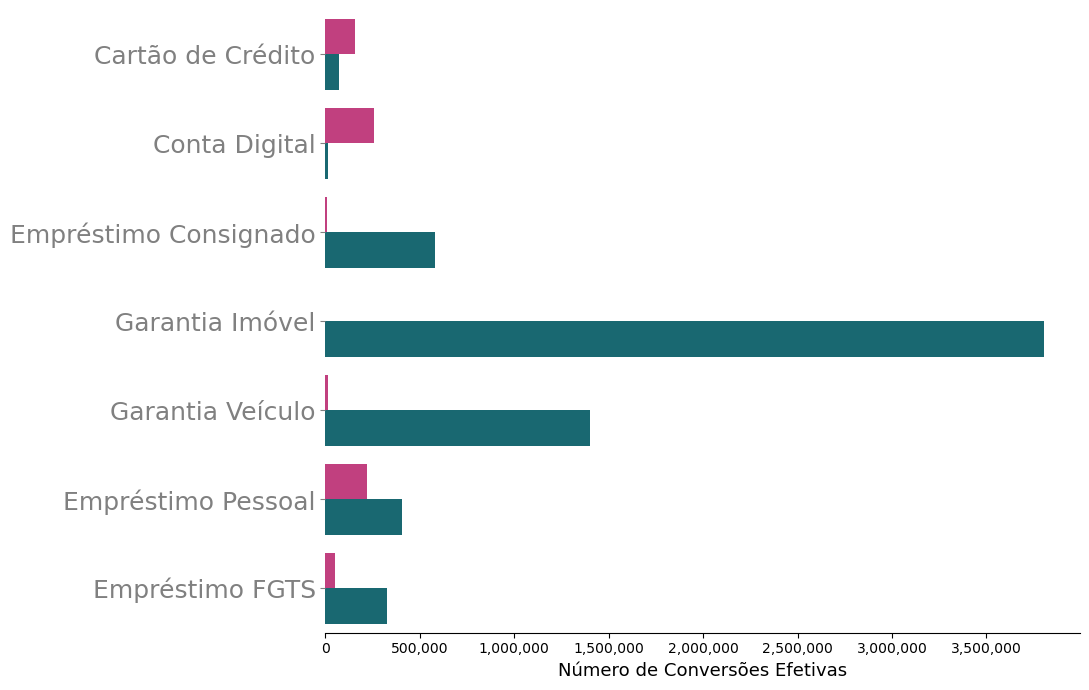

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ====================== PREPARAÇÃO DOS DADOS ======================
# df_atual já tem 'tipo_credito' e 'conversao_efetiva'
# df_otimizado tem 'tipo_credito' e 'conversao_efetiva*'

df_atual_agg = df_atual.groupby('tipo_credito')['conversao_efetiva'].sum().reset_index()
df_atual_agg['Tipo'] = 'Atual'

df_otim_agg = df_otimizado.groupby('tipo_credito')['conversao_efetiva*'].sum().reset_index()
df_otim_agg = df_otim_agg.rename(columns={'conversao_efetiva*': 'conversao_efetiva'})
df_otim_agg['Tipo'] = 'Otimizado'

# Junta os dois
df_plot = pd.concat([df_atual_agg, df_otim_agg], ignore_index=True)

# Nomes amigáveis para o gráfico
nome_produtos = {
    'cartao_credito': 'Cartão de Crédito',
    'conta_digital': 'Conta Digital',
    'emprestimo_consignado': 'Empréstimo Consignado',
    'emprestimo_garantia_imovel': 'Garantia Imóvel',
    'emprestimo_garantia_veiculo': 'Garantia Veículo',
    'emprestimo_pessoal': 'Empréstimo Pessoal',
    'emprestimo_pessoal_fgts': 'Empréstimo FGTS'
}
df_plot['Produto'] = df_plot['tipo_credito'].map(nome_produtos)

# ====================== GRÁFICO ======================
plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=df_plot,
    y='Produto',
    x='conversao_efetiva',
    hue='Tipo',
    palette=['#D72A7F', '#0B747F']  # atual, otimizado
)

# sem legenda
if ax.get_legend() is not None:
    ax.get_legend().remove()

#plt.title('Conversões Efetivas por Produto\nAntes × Depois da Otimização', fontsize=16, pad=20)
plt.xlabel('Número de Conversões Efetivas', fontsize=22)

plt.ylabel('')
#plt.legend(title='', fontsize=12)
ax.tick_params(axis='y', labelsize=18, colors='gray')
#ax.tick_params(axis='x', labelsize=16, colors='gray')

def m_formatter(x, pos):
    return f'{x/1_000_000:.1f}M'


ax.xaxis.set_major_formatter(plt.FuncFormatter(m_formatter))
ax.set_xlabel('Número de Conversões Efetivas', fontsize=13)
# Formata números grandes no eixo x
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

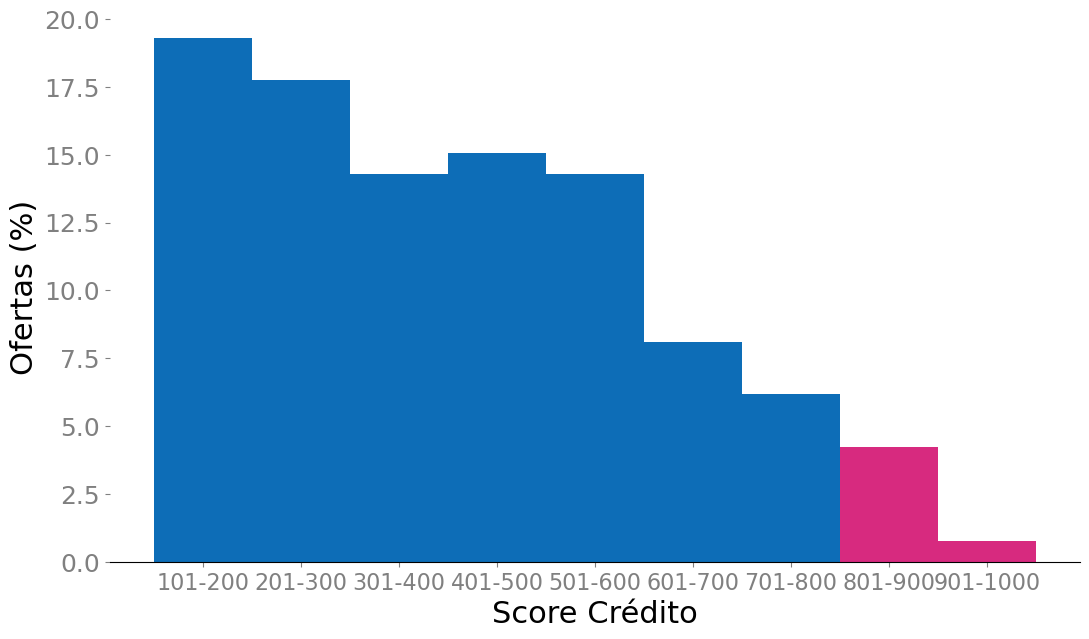

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Histograma da distribuição de ofertas de Garantia Imóvel por score (numérico)
midpoint_map = {
    '0-100': 50, '101-200': 150, '201-300': 250, '301-400': 350, '401-500': 450,
    '501-600': 550, '601-700': 650, '701-800': 750, '801-900': 850, '901-1000': 950
}

_tmp = df_otimizado[df_otimizado['tipo_credito'] == 'emprestimo_garantia_imovel'].copy()
_tmp['score_midpoint'] = _tmp['faixa_score_credito'].map(midpoint_map)

plt.figure(figsize=(11, 6.5))
ax = sns.histplot(
    data=_tmp,
    x='score_midpoint',
    bins=[100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    stat='percent',
    color='#0D6DB7',
    edgecolor='white',
    alpha=1
)
#plt.title('Distribuição das Ofertas de Garantia Imóvel por Faixa de Score', fontsize=14, pad=15)

plt.xlabel('Score Crédito', fontsize=22)
plt.ylabel('Ofertas (%)', fontsize=22)
plt.xticks([150, 250, 350, 450, 550, 650, 750, 850, 950],
           ['101-200', '201-300', '301-400', '401-500', '501-600', '601-700', '701-800', '801-900', '901-1000'])
#plt.grid(axis='y', alpha=0.3)
ax.tick_params(axis='y', labelsize=18, colors='gray')
ax.tick_params(axis='x', labelsize=16, colors='gray')
#plt.axvline(x=800, color='#0B747F', linestyle='--', linewidth=2, alpha=0.9)
# Destacar as barras 801-900 e 901-1000
for idx, p in enumerate(ax.patches):
    if idx in (7, 8):  # 0-based: 8ª e 9ª barras
        p.set_facecolor('#D72A7F')
# remove a separação visual entre barras
for p in ax.patches:
    p.set_linewidth(0)
    p.set_edgecolor(p.get_facecolor())
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

In [58]:
df_atual

,sk_produto,tipo_credito,sk_consumidor,faixa_etaria,faixa_score_credito,faixa_renda,flag_negativado,taxa_conversao,possui_oferta,conversao_efetiva,receita_gerada
0,1,conta_digital,1,0-20,301-400,0-1600,True,0.050971,10869.0,554.0,639.0
1,1,conta_digital,2,31-40,701-800,4001-5000,False,0.007333,28501.0,209.0,574.5
2,1,conta_digital,3,41-50,701-800,1601-2000,False,0.013875,7784.0,108.0,141.0
3,1,conta_digital,4,21-30,801-900,7001-8000,False,0.003628,1654.0,6.0,51.0
4,1,conta_digital,5,31-40,401-500,4001-5000,True,0.030186,52640.0,1589.0,1836.0
...,...,...,...,...,...,...,...,...,...,...,...
5812,7,emprestimo_garantia_imovel,1175,21-30,601-700,1601-2000,False,0.500000,2.0,1.0,123.0
5813,7,emprestimo_garantia_imovel,1178,41-50,801-900,8001-9000,False,0.000000,3.0,0.0,0.0
5814,7,emprestimo_garantia_imovel,1182,31-40,601-700,2001-3000,False,0.000000,2.0,0.0,0.0
5815,7,emprestimo_garantia_imovel,1189,31-40,501-600,4001-5000,False,0.307692,13.0,4.0,492.0


In [61]:
df_otimizado

,sk_produto,tipo_credito,sk_consumidor,faixa_etaria,faixa_score_credito,faixa_renda,flag_negativado,possui_oferta*,conversao_efetiva*,receita_gerada*
0,1,conta_digital,3,41-50,701-800,1601-2000,False,7643,106,134
1,1,conta_digital,4,21-30,801-900,7001-8000,False,1274,5,6
2,1,conta_digital,8,21-30,501-600,1601-2000,False,22353,320,405
3,1,conta_digital,12,51-60,501-600,9001+,False,8391,50,63
4,1,conta_digital,16,41-50,501-600,6001-7000,False,4097,31,39
...,...,...,...,...,...,...,...,...,...,...
1313,7,emprestimo_garantia_imovel,1294,71-80,101-200,4001-5000,False,1,0,51
1314,7,emprestimo_garantia_imovel,1295,71-80,101-200,4001-5000,True,4,2,275
1315,7,emprestimo_garantia_imovel,1300,51-60,0-100,1601-2000,True,2,1,114
1316,7,emprestimo_garantia_imovel,1303,80+,401-500,2001-3000,False,1,1,71


In [114]:
df_prod_atual = df_atual.groupby('tipo_credito').agg({'conversao_efetiva':'sum','possui_oferta':'sum','receita_gerada':'sum'})
df_prod_otimizado = df_otimizado.groupby('tipo_credito').agg({'conversao_efetiva*':'sum','possui_oferta*':'sum','receita_gerada*':'sum'})

In [67]:
df_prod_atual

,conversao_efetiva,possui_oferta,receita_gerada
sk_produto,,,
1,258128.0,8379359.0,326091.0
2,49345.0,190676.0,57268.5
3,219608.0,1230551.0,713703.0
4,12668.0,92792.0,208630.5
5,154900.0,8211683.0,1399411.5
6,7181.0,26867.0,8830.5
7,129.0,753.0,15867.0


In [68]:
df_prod_otimizado

,conversao_efetiva*,possui_oferta*,receita_gerada*
sk_produto,,,
1,14464,1295192,18271
2,324597,1295192,376724
3,405465,1295192,1317715
4,1400716,5310283,23068508
5,74074,1295192,669207
6,582549,1295192,716363
7,3805555,6346438,468083676


In [ ]:
# criar um histograma do